In [3]:
# Load some libraries
import os
import sys
import pandas as pd
import numpy as np

In [22]:
# Load the data from the crypto-market.csv file 

# Get the current directory (where the notebook is located)
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

# Get the parent directory 
parent_dir = os.path.dirname(current_dir)
print(f"Parent directory: {parent_dir}")

# Construct the path to the CSV file
csv_file_path = os.path.join(parent_dir, 'crypto-markets.csv')
print(f"CSV file path: {csv_file_path}")

# Check if the file exists
if os.path.exists(csv_file_path):
    # Load the CSV file
    df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded CSV file with {len(df)} rows and {len(df.columns)} columns")
    print(f"Columns: {list(df.columns)}")
    print("\nFirst few rows:")
    print(df.head())
else:
    print(f"File not found at: {csv_file_path}")

Current directory: /Users/josematiasvelastegui/UofT-DSI-Cohort5-ML-T1/Matias
Parent directory: /Users/josematiasvelastegui/UofT-DSI-Cohort5-ML-T1
CSV file path: /Users/josematiasvelastegui/UofT-DSI-Cohort5-ML-T1/crypto-markets.csv
Successfully loaded CSV file with 942297 rows and 13 columns
Columns: ['slug', 'symbol', 'name', 'date', 'ranknow', 'open', 'high', 'low', 'close', 'volume', 'market', 'close_ratio', 'spread']

First few rows:
      slug symbol     name        date  ranknow    open    high     low  \
0  bitcoin    BTC  Bitcoin  2013-04-28        1  135.30  135.98  132.10   
1  bitcoin    BTC  Bitcoin  2013-04-29        1  134.44  147.49  134.00   
2  bitcoin    BTC  Bitcoin  2013-04-30        1  144.00  146.93  134.05   
3  bitcoin    BTC  Bitcoin  2013-05-01        1  139.00  139.89  107.72   
4  bitcoin    BTC  Bitcoin  2013-05-02        1  116.38  125.60   92.28   

    close  volume        market  close_ratio  spread  
0  134.21     0.0  1.488567e+09       0.5438    3.88 


Checking for missing values:
slug           0
symbol         0
name           0
date           0
ranknow        0
open           0
high           0
low            0
close          0
volume         0
market         0
close_ratio    0
spread         0
dtype: int64

Data types:
slug            object
symbol          object
name            object
date            object
ranknow          int64
open           float64
high           float64
low            float64
close          float64
volume         float64
market         float64
close_ratio    float64
spread         float64
dtype: object

Descriptive statistics:
           slug  symbol     name        date        ranknow          open  \
count    942297  942297   942297      942297  942297.000000  9.422970e+05   
unique     2071    2005     2071        2043            NaN           NaN   
top     bitcoin    BITS  Bitcoin  2018-11-29            NaN           NaN   
freq       2042    3189     2042        2071            NaN           NaN   


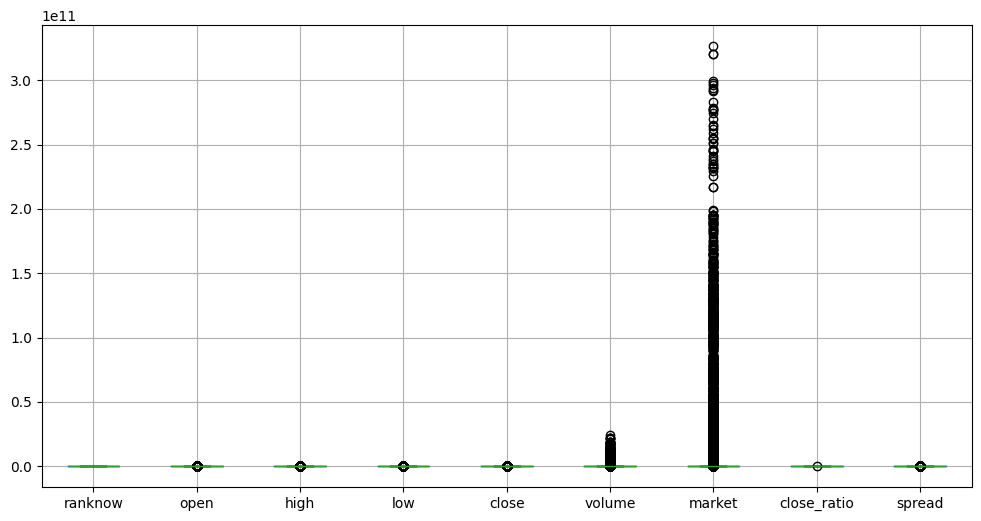

In [23]:
# Data inspection
print("\nChecking for missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nDescriptive statistics:")
print(df.describe(include='all'))

print("\nDuplicate rows:")
print(df.duplicated().sum())

# Visualize the data
import matplotlib.pyplot as plt
df.select_dtypes(include=[np.number]).boxplot(figsize=(12,6))
plt.show()

In [24]:
# --- 1. Remove rows with no meaningful trading data ---
# Drop rows where all prices and volume are zero
df = df[~((df['open'] == 0) & (df['close'] == 0) &
          (df['high'] == 0) & (df['low'] == 0) & (df['volume'] == 0))]

# --- 2. Handle market capitalization issues ---
# Flag rows where market cap is 0 but prices exist (likely missing supply data)
mask_bad_market = (df['market'] == 0) & (
    (df['open'] > 0) | (df['close'] > 0) | (df['high'] > 0) | (df['low'] > 0)
)

# Drop those rows 
df = df[~mask_bad_market]

# --- 3. Handle volume issues ---
# Flag zero-volume records that still have valid prices
df['volume_missing_flag'] = (df['volume'] == 0) & (
    (df['open'] > 0) | (df['close'] > 0) | (df['high'] > 0) | (df['low'] > 0)
)

# --- 4. Reset index and save cleaned dataset ---
df.reset_index(drop=True, inplace=True)
df.to_csv("crypto_cleaned.csv", index=False)

print("Cleaning complete. Saved as crypto_cleaned.csv")
print(f"Remaining rows: {len(df)}")
print(f"Rows flagged with missing volume: {df['volume_missing_flag'].sum()}")


Cleaning complete. Saved as crypto_cleaned.csv
Remaining rows: 824600
Rows flagged with missing volume: 23678


In [27]:
# Filter records with date >= 2013-12-27 to ensure we have volume data

# Ensure 'date' column is in datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Filter the DataFrame
df_filtered = df[df['date'] >= pd.Timestamp('2013-12-27')]
df_filtered.reset_index(drop=True, inplace=True)

print(f"Remaining rows: {len(df_filtered)}")

Remaining rows: 819318


In [28]:
# Recalculate daily rank by market capitalization

# For each date, rank coins by market capitalization (highest market cap = rank 1)
df_filtered['market_rank'] = df_filtered.groupby('date')['market'].rank(method='min', ascending=False)

# Show the result for the first few dates
print(df_filtered[['date', 'slug', 'market', 'market_rank']].head())

        date     slug        market  market_rank
0 2013-12-27  bitcoin  8.955395e+09          1.0
1 2013-12-28  bitcoin  8.869919e+09          1.0
2 2013-12-29  bitcoin  9.082104e+09          1.0
3 2013-12-30  bitcoin  9.217168e+09          1.0
4 2013-12-31  bitcoin  9.191325e+09          1.0


/var/folders/r3/cnfgms0529qcjggnzd7h1jjc0000gn/T/ipykernel_11667/3900566940.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['market_rank'] = df_filtered.groupby('date')['market'].rank(method='min', ascending=False)


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# Sort by coin and date
df_filtered = df_filtered.sort_values(['slug', 'date'])

# Create target: next day's close price
df_filtered['next_close'] = df_filtered.groupby('slug')['close'].shift(-1)

# Drop rows with missing target
df_model = df_filtered.dropna(subset=['next_close'])

# Select features
features = [
    'open', 'high', 'low', 'close', 'volume', 'market',
    'close_ratio', 'spread', 'market_rank'
]
X = df_model[features]
y = df_model['next_close']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and train MLPRegressor (neural network)
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = mlp.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}")

Test MSE: 13841856.9410


Test MAE: 101.7581
Test RMSE: 3720.4646
Test R²: 0.9183


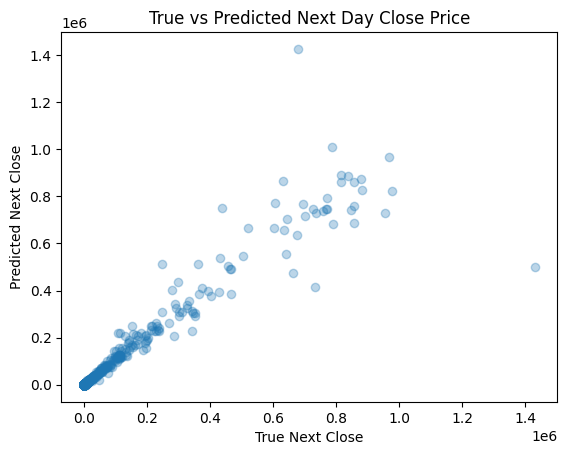

In [31]:
# Evaluate regression metrics
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

# Optional: Plot true vs predicted values
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("True Next Close")
plt.ylabel("Predicted Next Close")
plt.title("True vs Predicted Next Day Close Price")
plt.show()

In [33]:
from sklearn.ensemble import RandomForestRegressor

# Try a deeper neural network
mlp_deep = MLPRegressor(hidden_layer_sizes=(128, 64, 32), max_iter=300, random_state=42)
mlp_deep.fit(X_train_scaled, y_train)
y_pred_deep = mlp_deep.predict(X_test_scaled)

# Try Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [34]:
# Calculate RMSE manually 
mse_deep = mean_squared_error(y_test, y_pred_deep)
rmse_deep = np.sqrt(mse_deep)
print(f"Deep MLP Test RMSE: {rmse_deep:.4f}")

# Calculate RMSE for Random Forest
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
print(f"Random Forest Test RMSE: {rmse_rf:.4f}")

Deep MLP Test RMSE: 3525.5831
Random Forest Test RMSE: 3798.6583


In [36]:
from sklearn.metrics import mean_absolute_error, r2_score

# MLPRegressor (shallow)
mae_mlp = mean_absolute_error(y_test, y_pred)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred))
r2_mlp = r2_score(y_test, y_pred)
print("MLPRegressor (shallow):")
print(f"Test MAE: {mae_mlp:.4f}")
print(f"Test RMSE: {rmse_mlp:.4f}")
print(f"Test R²: {r2_mlp:.4f}\n")

# MLPRegressor (deep)
mae_deep = mean_absolute_error(y_test, y_pred_deep)
rmse_deep = np.sqrt(mean_squared_error(y_test, y_pred_deep))
r2_deep = r2_score(y_test, y_pred_deep)
print("MLPRegressor (deep):")
print(f"Test MAE: {mae_deep:.4f}")
print(f"Test RMSE: {rmse_deep:.4f}")
print(f"Test R²: {r2_deep:.4f}\n")

# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest:")
print(f"Test MAE: {mae_rf:.4f}")
print(f"Test RMSE: {rmse_rf:.4f}")
print(f"Test R²: {r2_rf:.4f}")

MLPRegressor (shallow):
Test MAE: 101.7581
Test RMSE: 3720.4646
Test R²: 0.9183

MLPRegressor (deep):
Test MAE: 64.9519
Test RMSE: 3525.5831
Test R²: 0.9266

Random Forest:
Test MAE: 60.7259
Test RMSE: 3798.6583
Test R²: 0.9148


In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.neural_network import MLPClassifier
# from sklearn.metrics import accuracy_score

# # Create binary target: 1 if next day's close is higher, 0 otherwise
# df_model.loc[:, 'up_down'] = (df_model['next_close'] > df_model['close']).astype(int)

# # Features and target
# X = df_model[features]
# y = df_model['up_down']
# coins = df_model['slug']

# # Train-test split
# X_train, X_test, y_train, y_test, coins_train, coins_test = train_test_split(
#     X, y, coins, test_size=0.2, random_state=42
# )

# # Feature scaling
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Train classifier
# clf = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42)
# clf.fit(X_train_scaled, y_train)

# # Predict on test set
# y_pred = clf.predict(X_test_scaled)

# # Calculate efficiency (accuracy) per coin
# coin_metrics = []
# for coin in coins_test.unique():
#     idx = coins_test == coin
#     if sum(idx) > 0:
#         acc = accuracy_score(y_test[idx], y_pred[idx])
#         coin_metrics.append((coin, acc, sum(idx)))

# # Sort by accuracy and show top 20 coins
# coin_metrics_sorted = sorted(coin_metrics, key=lambda x: x[1], reverse=True)
# print("Top 20 coins by prediction accuracy on test set:")
# print("Coin\tAccuracy\tTest Samples")
# for coin, acc, n in coin_metrics_sorted[:20]:
#     print(f"{coin}\t{acc:.3f}\t{n}")